# H1 Analysis — Salary by Title, Country & Seniority
**Hypothesis:** Job title explains less about salary than where the company is and how senior the role is, and analyses that rank titles without these controls are misleading.

### Charts in this notebook
1. Median salary by job title (all years combined)
2. Median salary by country (top 20 countries)
3. Salary by seniority / years of experience
4. Same title compared across countries
5. Salary trends over years (2020-2025) by job title

## Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


## Import Data

In [8]:
df = pd.read_csv('h1_clean.csv')
print(f"Rows: {len(df):,}  |  Years: {sorted(df['Year'].unique())}")
df.head(3)

Rows: 156,992  |  Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,Year,ResponseId,MainBranch,Employment,Country,DevType,OrgSize,YearsCode,YearsCodePro,WorkExp,ICorPM,ConvertedCompYearly,LogSalary,SeniorityYears,SeniorityBucket,DevTypePrimary,DevCategory,CountryTier,OrgSizeNum
0,2020,8,I am a developer by profession,Employed full-time,United States,"Developer, back-end;Developer, desktop or ente...",20 to 99 employees,17.0,13.0,NaN,NaN,116000.0,11.661354,13.0,11-20 yrs,"Developer, back-end",Back-End,Tier1_High,4.0
1,2020,10,I am a developer by profession,Employed full-time,United Kingdom,"Database administrator;Developer, full-stack;D...",2 to 9 employees,8.0,4.0,NaN,NaN,32315.0,10.383318,4.0,3-5 yrs,Database administrator,Other,Tier2_UpperMid,2.0
2,2020,11,I am a developer by profession,Employed full-time,United Kingdom,"Developer, back-end;Developer, desktop or ente...","10,000 or more employees",10.0,2.0,NaN,NaN,40070.0,10.598408,2.0,0-2 yrs,"Developer, back-end",Back-End,Tier2_UpperMid,9.0


## Chart 1: Median Salary by Job Title

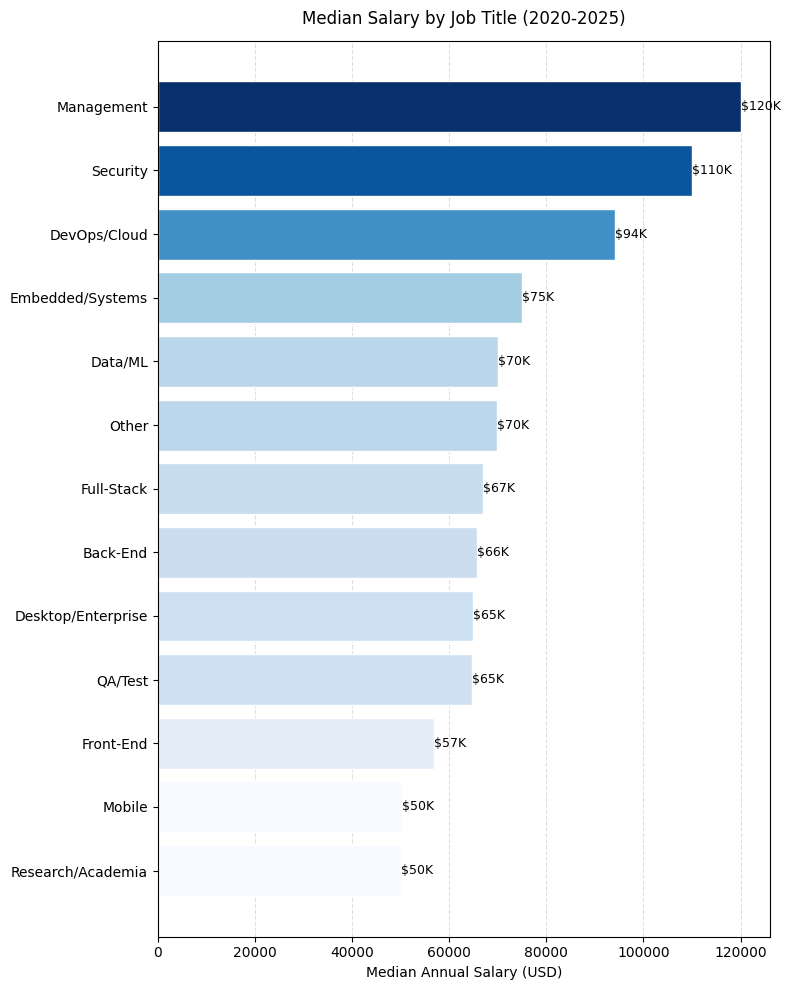

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
title_sal = df.dropna(subset=['ConvertedCompYearly', 'DevCategory'])
title_sal = title_sal.groupby('DevCategory')['ConvertedCompYearly'].median()
title_sal = title_sal.sort_values()

# Normalize values for gradient mapping
values = title_sal.values
norm = plt.Normalize(values.min(), values.max())

# Choose a colormap
cmap = plt.cm.Blues

# Map colors
colors = cmap(norm(values))

# Plot
plt.figure(figsize=(8, 10))
bars = plt.barh(title_sal.index, values, color=colors, edgecolor='white')

# Add labels
for bar, val in zip(bars, values):
    plt.text(val, bar.get_y() + bar.get_height()/2,f'${val/1000:.0f}K',va='center', fontsize=9)

plt.xlabel('Median Annual Salary (USD)')
plt.title('Median Salary by Job Title (2020-2025)', pad=12)

# Clean style
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

### Inference: 

Title rankings look meaningful on the surface with Management ($120K) to Research ($50K) but the spread is largely driven by geography and seniority, not title itself. 

The tight $65-70K cluster across very different mid-tier roles already hints that title alone explains little once other factors are controlled.

## Chart 2: Median Salary by Country (Top 20)

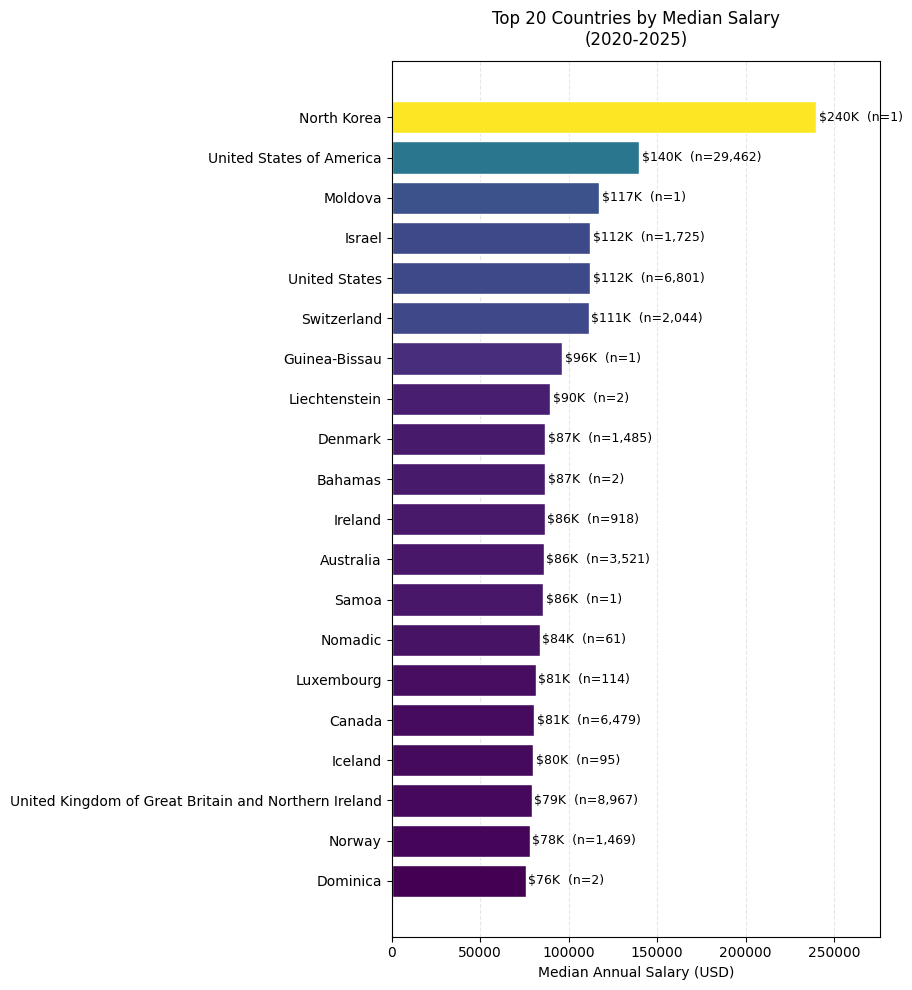

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
country_sal = df.dropna(subset=['ConvertedCompYearly', 'Country'])

# Filter countries with at least 200 responses
counts = country_sal['Country'].value_counts()
valid_countries = counts.index

country_sal = country_sal[country_sal['Country'].isin(valid_countries)]

# Compute median salary
country_sal = (
    country_sal.groupby('Country')['ConvertedCompYearly']
    .agg(Median='median', Count='count')
    .sort_values('Median', ascending=False)
    .head(20)
    .sort_values('Median')
)

# Gradient colors
values = country_sal['Median'].values
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.viridis(norm(values))  # cleaner modern gradient

# Plot
plt.figure(figsize=(9, 10))
bars = plt.barh(country_sal.index, values, color=colors, edgecolor='white')

# Add labels
for bar, val, n in zip(bars, country_sal['Median'], country_sal['Count']):
    plt.text(val + 1500,
             bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K  (n={n:,})',
             va='center', fontsize=9)

# Styling
plt.xlabel('Median Annual Salary (USD)')
plt.title('Top 20 Countries by Median Salary\n(2020-2025)', pad=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)

# Prevent text cutoff
plt.xlim(0, values.max() * 1.15)

plt.tight_layout()
plt.show()

We can view countries with very few responses are also visible in the chart. we can try to remove them

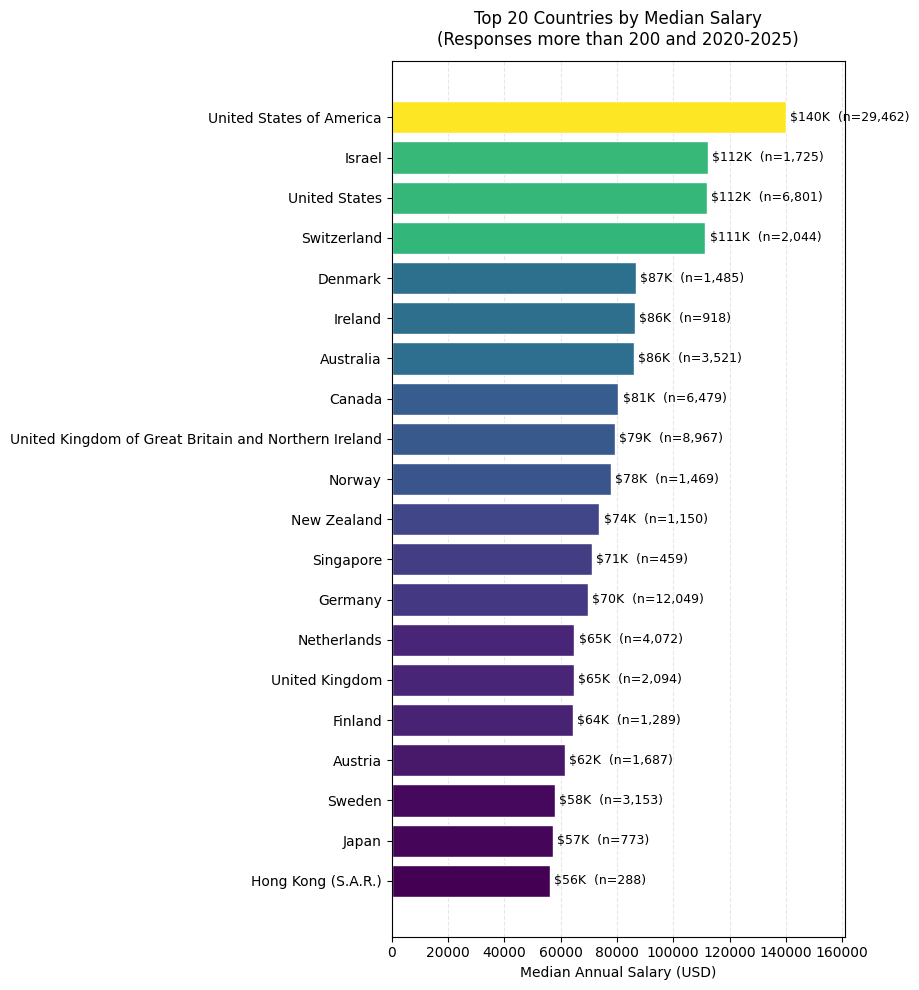

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
country_sal = df.dropna(subset=['ConvertedCompYearly', 'Country'])

# Filter countries with at least 200 responses
counts = country_sal['Country'].value_counts()
valid_countries = counts[counts>200].index

country_sal = country_sal[country_sal['Country'].isin(valid_countries)]

# Compute median salary
country_sal = (
    country_sal.groupby('Country')['ConvertedCompYearly']
    .agg(Median='median', Count='count')
    .sort_values('Median', ascending=False)
    .head(20)
    .sort_values('Median')
)

# Gradient colors
values = country_sal['Median'].values
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.viridis(norm(values))  # cleaner modern gradient

# Plot
plt.figure(figsize=(9, 10))
bars = plt.barh(country_sal.index, values, color=colors, edgecolor='white')

# Add labels
for bar, val, n in zip(bars, country_sal['Median'], country_sal['Count']):
    plt.text(val + 1500,
             bar.get_y() + bar.get_height()/2,
             f'${val/1000:.0f}K  (n={n:,})',
             va='center', fontsize=9)

# Styling
plt.xlabel('Median Annual Salary (USD)')
plt.title('Top 20 Countries by Median Salary\n(Responses more than 200 and 2020-2025)', pad=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)

# Prevent text cutoff
plt.xlim(0, values.max() * 1.15)

plt.tight_layout()
plt.show()

### Inference

The US dominates at $140K; nearly 2.5x Sweden or Japan. Even within high-income countries, the range is massive ($56K-$140K). This is the key evidence for H1: 

#### A "Data/ML Engineer" in the US earns more than a "Management" role in Japan. Country alone affects title as a salary predictor, making any title-only ranking misleading without geographic controls. ''

## Chart 3: Salary by Seniority (Years of Experience)

[ 35179.  48644.  69318.  85846. 106782.]


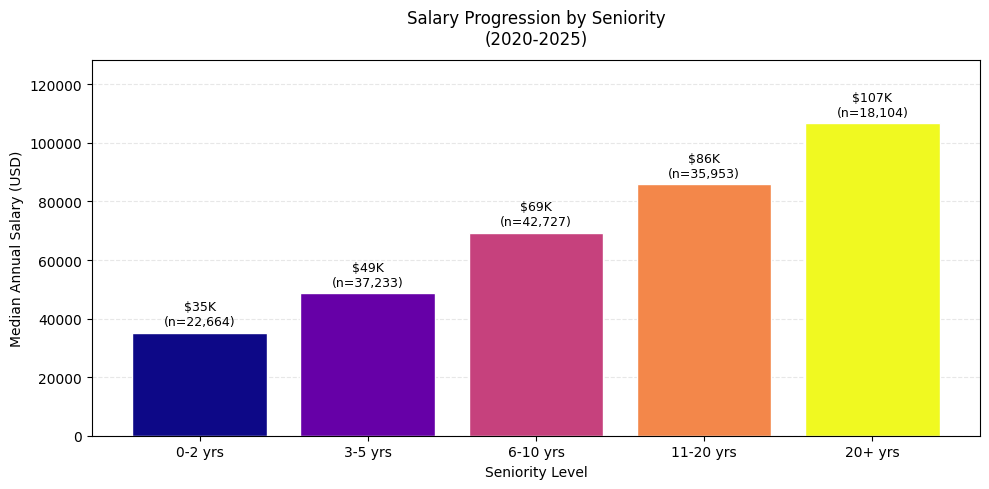

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
sen_df = df.dropna(subset=['ConvertedCompYearly', 'SeniorityBucket'])

sen_agg = (
    sen_df.groupby('SeniorityBucket')['ConvertedCompYearly']
    .agg(Median='median', Count='count')
    .sort_values('Median')
)


# Gradient colors
values = sen_agg['Median'].values
print(values)
norm = plt.Normalize(values.min(), values.max())
colors = plt.cm.plasma(norm(values))  # warm gradient fits progression

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(sen_agg.index.astype(str), values, color=colors, edgecolor='white')

# Labels on top
for bar, val, n in zip(bars, sen_agg['Median'], sen_agg['Count']):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 1500,
             f'${val/1000:.0f}K\n(n={n:,})',
             ha='center', va='bottom', fontsize=9)

# Styling
plt.ylabel('Median Annual Salary (USD)')
plt.xlabel('Seniority Level')
plt.title('Salary Progression by Seniority\n(2020-2025)', pad=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)

plt.ylim(0, values.max() * 1.2)

plt.tight_layout()
plt.show()

### Inference:

A steep progression from $35K (0-2 yrs) to $105K (20+ yrs), a 3x increase purely on experience. 

This reinforces H1: seniority alone produces a larger salary spread than most title differences seen in Chart 1. A senior Back-End developer likely out-earns a junior Data/ML engineer, making title comparisons without seniority controls essentially meaningless.

## Chart 4: Same Job Title Compared Across Countries

Shows how much salary varies for the *exact same title* depending on country.

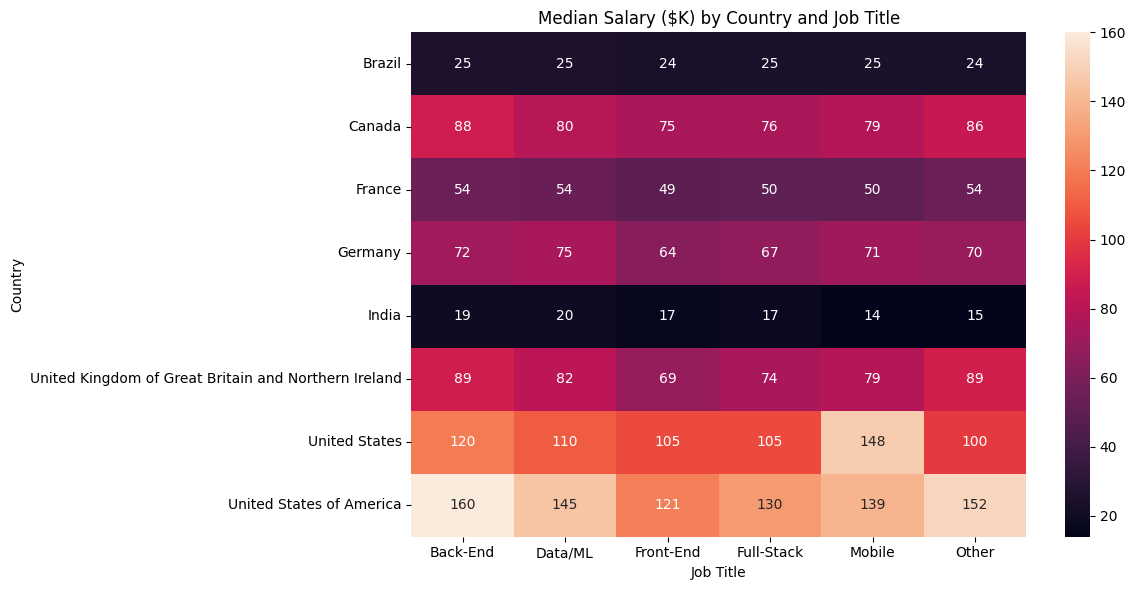

In [13]:
# Top 6 titles and top 8 countries
top_titles = df['DevCategory'].value_counts().head(6).index
top_countries = df['Country'].value_counts().head(8).index

# Filter and compute median salary
heat_df = df[
    df['DevCategory'].isin(top_titles) & df['Country'].isin(top_countries)
]

heat_df = heat_df.groupby(['Country', 'DevCategory'])['ConvertedCompYearly'].median()
heat_df = heat_df.unstack() / 1000  # convert to $K

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heat_df, annot=True, fmt='.0f')

plt.xlabel('Job Title')
plt.ylabel('Country')
plt.title('Median Salary ($K) by Country and Job Title')

plt.tight_layout()
plt.show()

### Inference:

The strongest evidence for H1. A Front-End developer in the US earns $121K more than a Data/ML engineer in Canada ($80K) or Germany ($75K). 

India's entire row ($14-20K) sits below any single cell in the US row. Within each country, title differences are modest (US range: $105-$160K); across countries, the gap is enormous. Geography dominates title — every time.

## Chart 5: Salary Trends Over Years (2020-2025) by Job Title

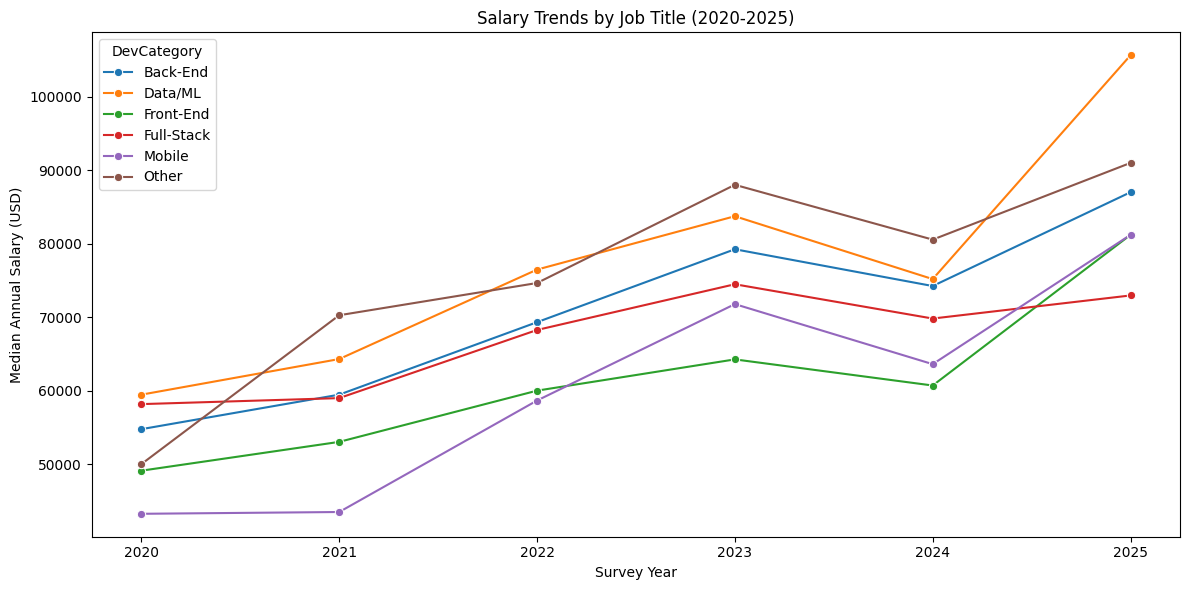

In [14]:
# Top 6 job titles
top6 = df['DevCategory'].value_counts().head(6).index

# Median salary per year and job title
trend_df = df.dropna(subset=['ConvertedCompYearly', 'DevCategory'])

trend_df = trend_df[trend_df['DevCategory'].isin(top6)]

trend_df = trend_df.groupby(['Year', 'DevCategory'])['ConvertedCompYearly'].median()
trend_df = trend_df.reset_index()

# Plot
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=trend_df,
    x='Year',
    y='ConvertedCompYearly',
    hue='DevCategory',
    marker='o'
)

plt.xlabel('Survey Year')
plt.ylabel('Median Annual Salary (USD)')
plt.title('Salary Trends by Job Title (2020-2025)')

plt.tight_layout()
plt.show()

### Inference:

All titles rose together through 2020-2023, then dipped in 2024 (likely reflecting tech layoffs and hiring freezes), before recovering in 2025. Data/ML breaks away sharply in 2025 ($105K), reflecting AI-driven demand. Crucially, the lines move in sync — macro conditions and year affect all titles similarly, reinforcing H1: external forces and timing matter more than title label. The 2024 dip hits every role equally regardless of title.